# PBCO historgram plot of all the modes

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import pandas as pd
import tensorflow as tf
from importlib import reload
import P2_alris_one_third_functions as P2_alris_one_third_functions
reload(P2_alris_one_third_functions)
from P2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list

number_of_modes = 52

In [13]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """

    # Get modified structure
    pars_tensor = tf.stack(pars)  # shape (params,)

    #t0 = time()
    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    #print(f"atom_shift_list time: {time() - t0:.4f} seconds")
    atom_shift_list = atom_shift_list[:,0]

    atom_shift_list = tf.unstack(atom_shift_list)
    #convert atom_shift_list to a numpy array
    #t0 = time()
    modified_struct = atom_position_list(*atom_shift_list)
    #print(f"Time taken for atom_positionList: {time() - t0:.4f} seconds")
    
    hkl_list = transform_list_hkl_p63_p65(hkl_list)

    # Get structure factors

    sf_hkl = get_structure_factors(hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(hkl_list, tf.float32), axis=1)
    max_intensity = np.max(intensity)
    intensity = np.where(intensity < max_intensity * 0.01, tf.zeros_like(intensity), intensity)  # Ensure no negative intensities
    intensity = intensity * tf.exp(- w* qnorms ** 2)  # Apply Debye-Waller factor
    intensity = intensity / tf.reduce_max(intensity)
    intensity = intensity / tf.reduce_sum(intensity) * 60
    return intensity



In [14]:
def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.max(data['intensity_exp'])
    exp_intensity = exp_intensity / np.sum(exp_intensity) * 60
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

In [15]:
def calculate_structure_factor(iteration, histogram_matrix):
    exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K.csv')
    n_features = exp_data.shape[0]
    n_dim = 3
    hkl_list = exp_data[["h", "k", "l"]].values.tolist()
    hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)
    features = hkl_list

    labels = exp_data["intensity_exp"].tolist()
    labels = labels / np.max(labels)  # Normalize labels
    labels = labels / np.sum(labels) * 60 # Normalize labels

    # #initialise
    best_model_pars = histogram_matrix[iteration, :]
    best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   

    matrix = np.loadtxt('P2_matrix.txt', dtype=np.float32)
    #convert matrix to tensor
    matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)
    exp_data['intensity_sim'] = fun_tf(features, best_model_pars , matrix).numpy()
    

    r_factor = alris_r_factor(exp_data)
    print(f"ALRIS R-factor: {r_factor:.3f}")

    return exp_data, r_factor


# 300K data

(52, 1000)
Minimum loss index: 158
Minimum loss value: 1.644
Minimum R-factor index: 611
ALRIS R-factor: 0.766
R-factor: 0.766


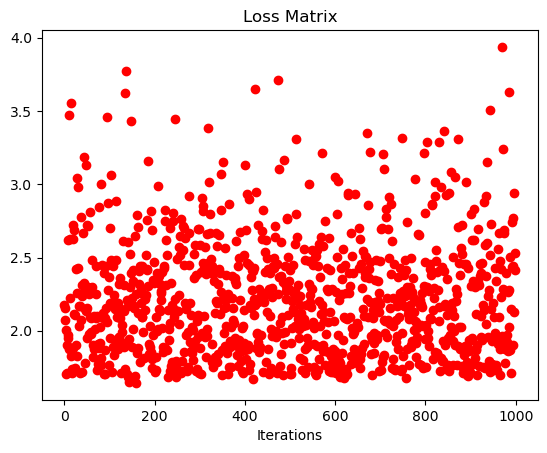

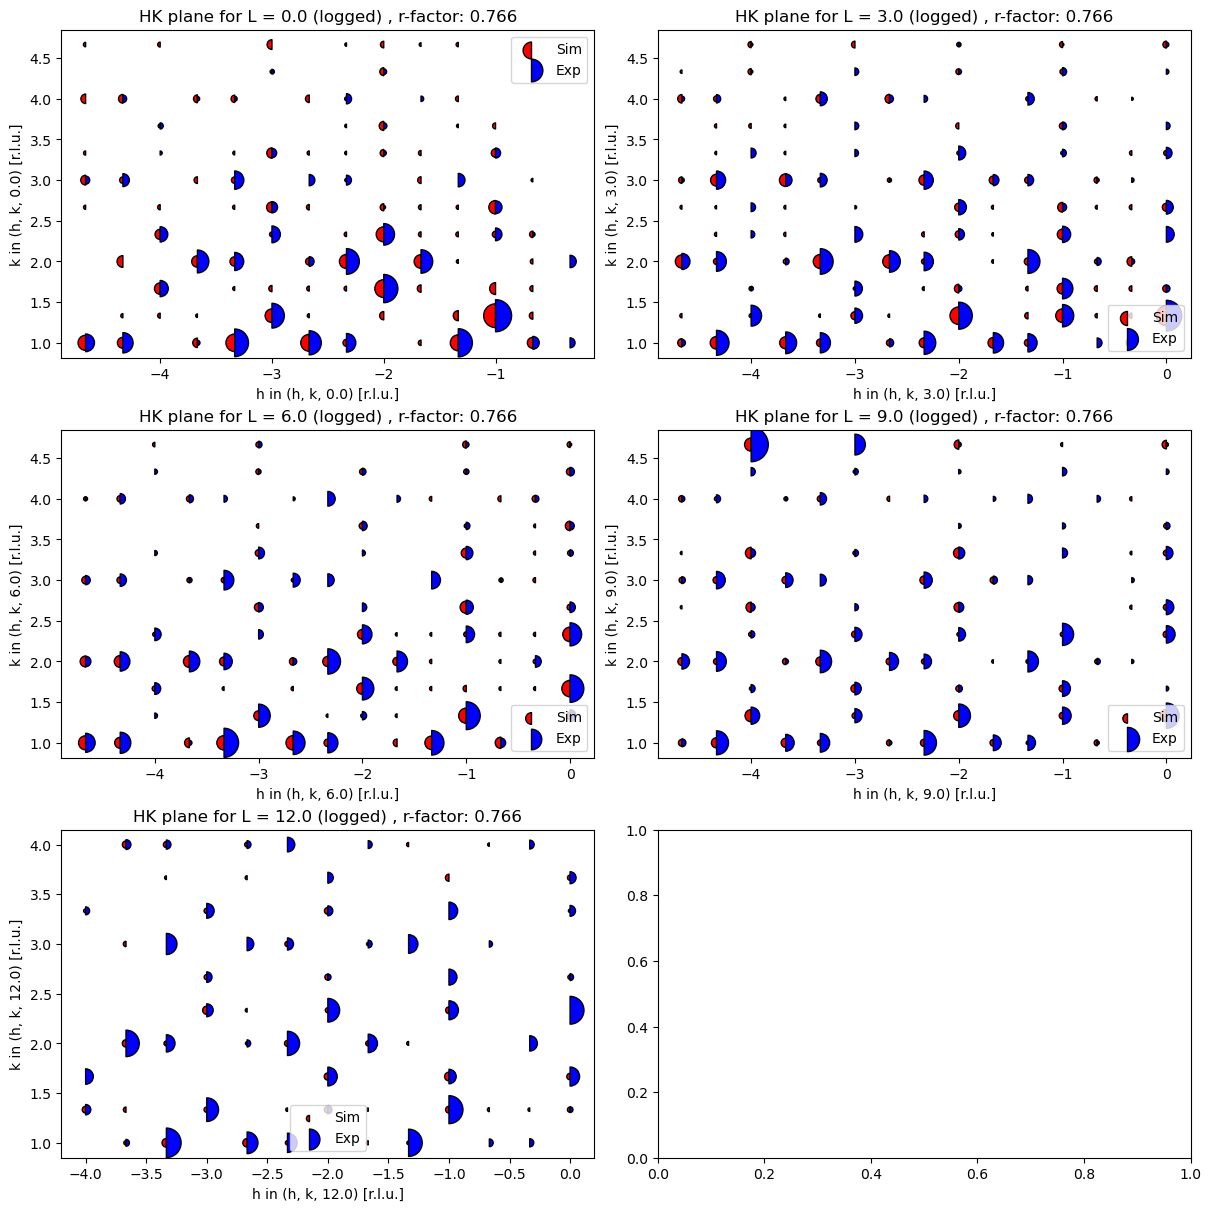

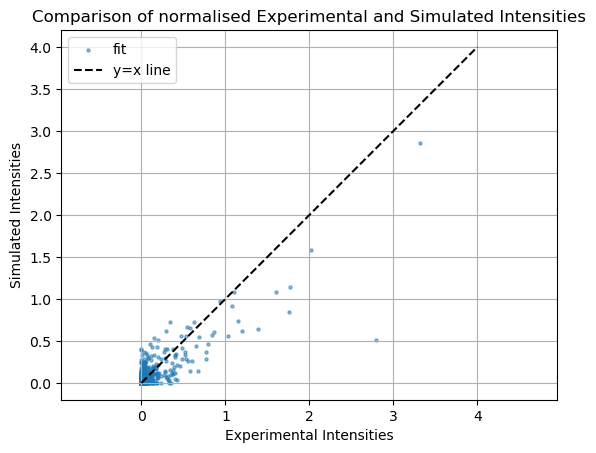

In [18]:
#load file 
number_of_modes = 52
histogram = np.load('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/20250914_101604_iters1000_epochs150_lr0.02/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=True)

plt.show()

x = np.linspace(0 ,4, 100)
y = x
plt.scatter(exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 60, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of normalised Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()

(156, 2000)
Minimum loss index: 1536
Minimum loss value: 17.381
ALRIS R-factor: 0.633
R-factor: 0.633


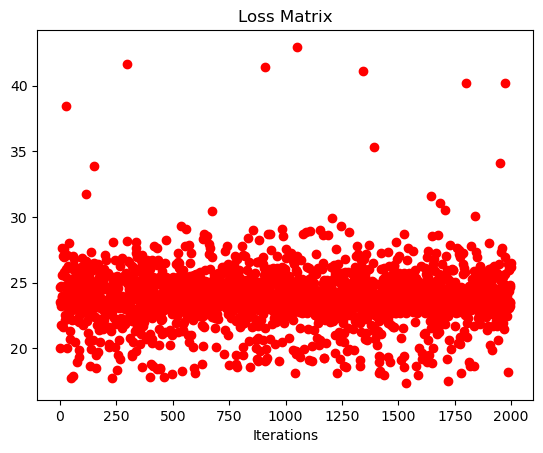

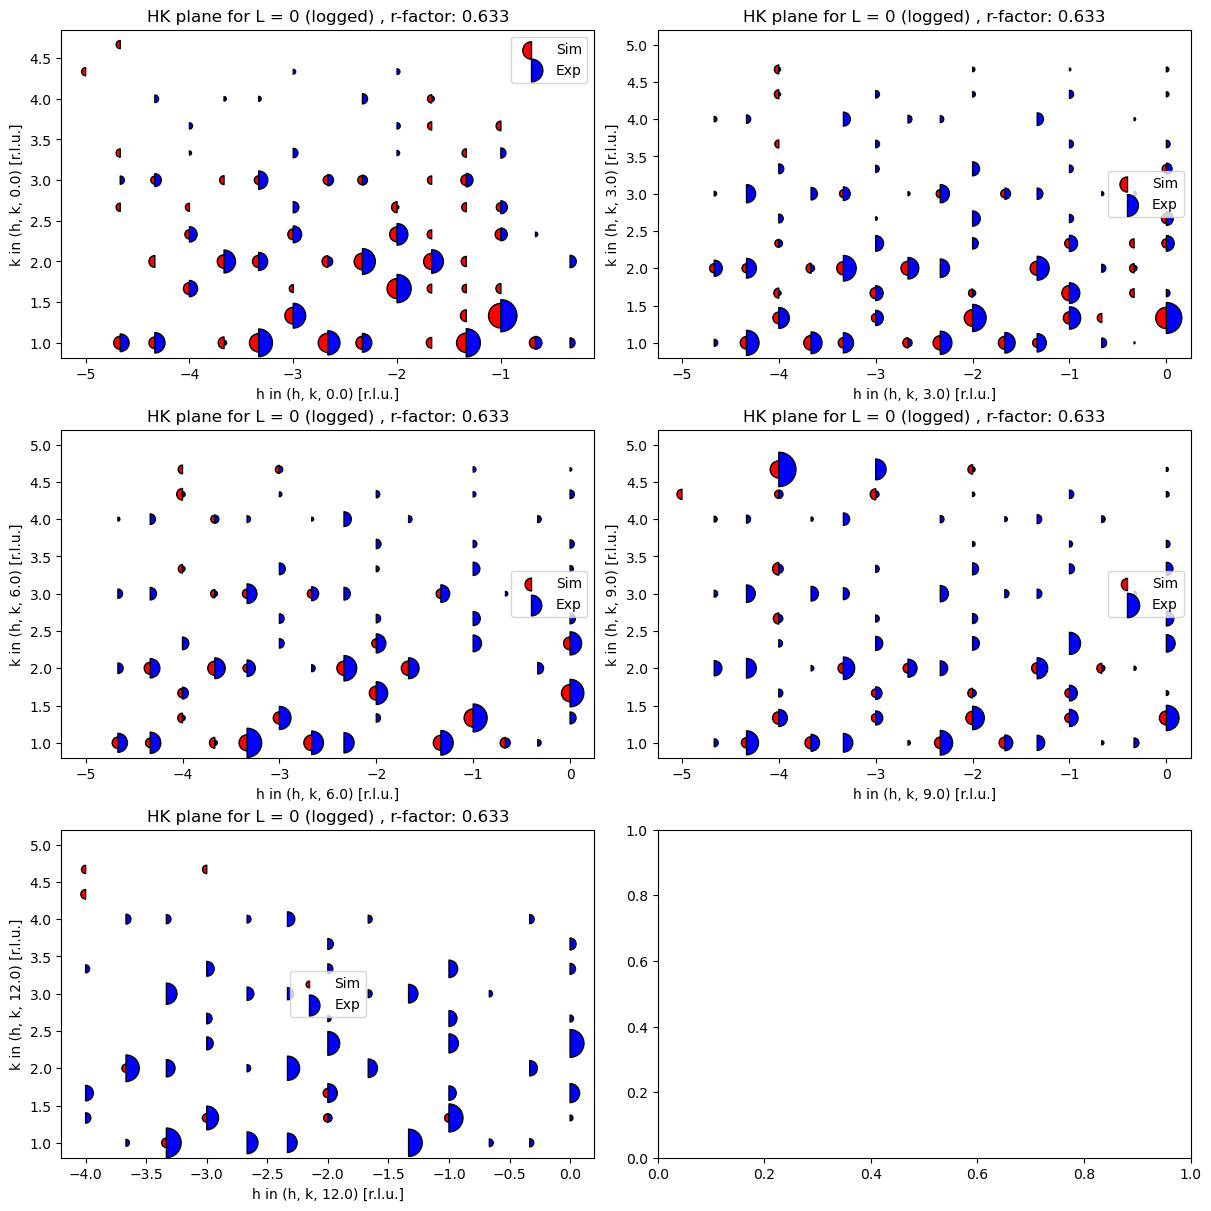

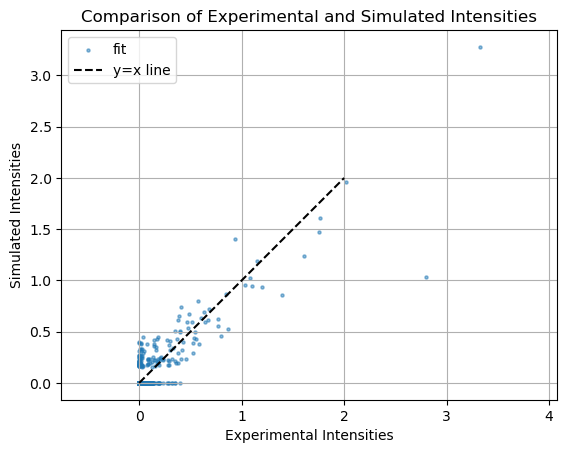

In [16]:
#load file 
number_of_modes = 156
histogram = np.load('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/results/20250904_040738_iters2000_epochs75_lr0.08/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=True)

plt.show()

x = np.linspace(0 ,2, 100)
y = x
plt.scatter(exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 60, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()